# Validation Pipeline Sketch V1

## 0. Imports and Set-Up:

In [1]:
import multiprocessing
# import sys
# import logging

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from utils import *
from typing import Type, Any, Optional
from pathlib import Path
from sklearn.model_selection import train_test_split

from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score, f1_score, confusion_matrix, silhouette_score, pairwise_distances
from sklearn.utils import check_random_state
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from matplotlib.ticker import MultipleLocator
import umap
from sklearn.preprocessing import LabelEncoder

from scipy.optimize import linear_sum_assignment
from scipy.stats import multivariate_normal
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm

from joblib import Parallel, delayed
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def cluster_stability(X, clusterer,
                      subsample_frac=0.8, n_runs=100):
    """
    Cluster stability index

    Computes the cluster stability index using the Jaccard similarity
    coefficient between two clusterings, obtained using two random 
    subsamples of the data. Implements the method described in
    Ben-Hur (2002).

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Data matrix
    clusterer : object
        Clustering estimator with fit_predict method
    subsample_frac : float, default=0.8
        Fraction of data to subsample
    n_runs : int, default=100
        Number of runs for cluster stability computation

    Returns
    -------
    stability : float
        Cluster stability index
    stability_dist : list
        List of cluster stability values for each run
    """
    X = pd.DataFrame(X)
    n_samples = X.shape[0]
    stability_dist = []
    for _ in range(n_runs):
        # get two subsamples of the data
        idx1 = np.random.choice(n_samples, int(subsample_frac*n_samples), replace=False)
        idx2 = np.random.choice(n_samples, int(subsample_frac*n_samples), replace=False)
        X1, X2 = X.iloc[idx1, :], X.iloc[idx2, :]
        
        # cluster using each subsample
        labels1 = clusterer.fit_predict(X1)
        labels2 = clusterer.fit_predict(X2)

        labels_mat = np.zeros((n_samples, 2))
        labels_mat[idx1, 0] = labels1
        labels_mat[idx2, 1] = labels2

        # compute jaccard similarity between clusterings
        joint_idx = np.intersect1d(idx1, idx2)
        stability_dist.append(adjusted_rand_score(labels_mat[joint_idx, 0], labels_mat[joint_idx, 1]))
    stability = np.mean(stability_dist)
    return stability, stability_dist


def jaccard_similarity(x, y):
    """
    Jaccard similarity coefficient between two cluster membership vectors

    Parameters
    ----------
    x : array-like, shape (n_samples,)
        Cluster membership vector
    y : array-like, shape (n_samples,)
        Cluster membership vector

    Returns
    -------
    jaccard : float
        Jaccard similarity coefficient
    """
    x = np.array(x)
    y = np.array(y)

    # nxn neighborhood matrix with 0s on diagonal
    C_x = np.equal.outer(x, x).astype(int)
    np.fill_diagonal(C_x, 0)
    C_y = np.equal.outer(y, y).astype(int)
    np.fill_diagonal(C_y, 0)
    
    # compute jaccard similarity
    N11 = np.sum(C_x * C_y)
    j = N11 / (np.sum(C_x) + np.sum(C_y) - N11)
    return j

In [3]:
def compute_consensus_matrix(
    X, 
    clusterer, 
    n_runs=100, 
    subsample_frac=0.8, 
    random_state=None
):
    """
    Compute the NxN consensus matrix where entry (i,j) is the fraction
    of times samples i and j were clustered together across bootstrap runs.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    clusterer : any sklearn‐like estimator with fit_predict(X_sub) method
    n_runs : int
        Number of bootstrap runs.
    subsample_frac : float in (0,1]
        Fraction of samples to draw (without replacement) each run.
    random_state : int or None
        
    Returns
    -------
    consensus : ndarray, shape (n_samples, n_samples)
        consensus[i,j] ∈ [0,1]
    """
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    co_mat   = np.zeros((n, n), dtype=float)
    samp_mat = np.zeros((n, n), dtype=float)
    all_idx  = np.arange(n)
    
    for _ in range(n_runs):
        # 1) subsample indices
        subs = rng.choice(all_idx, size=int(subsample_frac*n), replace=False)
        X_sub = X[subs]
        
        # 2) cluster that subsample
        labels = clone(clusterer).fit_predict(X_sub)
        
        # 3) increment counts for pairs sampled together
        ii, jj = np.meshgrid(subs, subs, indexing='ij')
        samp_mat[ii, jj] += 1
        
        # 4) for each cluster, mark co‐occurrence
        for lbl in np.unique(labels):
            in_clust = subs[labels == lbl]
            if len(in_clust) > 1:
                i2, j2 = np.meshgrid(in_clust, in_clust, indexing='ij')
                co_mat[i2, j2] += 1
    
    # 5) build consensus by dividing
    with np.errstate(divide='ignore', invalid='ignore'):
        consensus = co_mat / samp_mat
    consensus[np.isnan(consensus)] = 0.
    return consensus

In [4]:
RANDOM_SEED = 1453
np.random.seed(RANDOM_SEED)

### 0.1 Data Import:

In [5]:
data_dir = Path('./data/DARMANIS')
data_fp = data_dir / 'GBM_raw_gene_counts.csv'
labels_fp = data_dir / 'GBM_metadata.csv'

In [6]:
# import pandas as pd

# # 1) Define a regex that matches a single space only if it's not inside quotes:
# sep_regex = r'\s(?=(?:[^"]*"[^"]*")*[^"]*$)'

# # 2) Read with the Python engine (so it honors regex sep + quotechar)
# meta = pd.read_csv(
#     labels_fp,
#     sep=sep_regex,
#     engine="python",
#     quotechar='"',
#     skipinitialspace=True  # drop any spurious space after splitting
# )

# # 3) Clean up column names (strip any remaining quotes)
# meta.columns = [col.strip('"') for col in meta.columns]

# # 4) (Optional) Convert obvious numeric columns
# numeric = [
#     "Total_reads","Unique_reads","Unique_reads_percent",
#     "Splice_sites_total","Splice_sites_Annotated","Splice_sites_GT.AG",
#     "Splice_sites_GC.AG","Splice_sites_AT.AC","Splice_sites_non_canonical",
#     "Multimapping_reads_percent","Unmapped_mismatch","Unmapped_short",
#     "Unmapped_other","ERCC_reads","Non_ERCC_reads","ERCC_to_non_ERCC",
#     "Genes_detected","Cluster_2d"
# ]
# for c in numeric:
#     if c in meta:
#         meta[c] = pd.to_numeric(meta[c], errors="coerce")
# meta.index = meta.index.str.replace(r'^"|"$', '', regex=True)
# print(meta.head())

In [7]:
# # regex: split on a space only if it’s not inside "...“
# sep_regex = r'\s(?=(?:[^"]*"[^"]*")*[^"]*$)'

# df = pd.read_csv(
#     data_fp,
#     sep=sep_regex,
#     engine="python",
#     quotechar='"',
#     header=0,
#     skipinitialspace=True
# )

# # strip any remaining quotes from the column names
# df.columns = [c.strip('"') for c in df.columns]
# df = df.T
# print(df.shape)
# print(df.columns[:5])
# print(df.head())

In [8]:

# adata = ad.AnnData(
#     X=df.values,
#     obs=meta.loc[df.index],
#     var=pd.DataFrame(index=df.columns)
# )
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)
# adata.write_h5ad("data/darmanis_fromraw.h5ad")
# adata

In [9]:
# tsne_df = pd.read_csv("GBM_TSNE", index_col=0)  
# # or however you have them in memory:
# # tsne_df = pd.DataFrame(tsne_og, index=adata.obs_names, columns=['TSNE1','TSNE2'])

# # --- 3) add to adata.obsm ---
# adata.obsm['X_tsne_og'] = tsne_df.loc[adata.obs_names].values

# # --- 4) (optional) save ---
# adata.write_h5ad("data/darmanis_with_tsne_og.h5ad")

# # Now you can plot it in Scanpy:
# sc.pl.embedding(
#     adata, 
#     basis='tsne_og', 
#     color=['Location','Selection'], 
#     title=['Original t-SNE by Location','Original t-SNE by Selection']
# )

### 0.2 Importing raw data

In [10]:
adata = ad.read_h5ad('data/darmanis_fromraw.h5ad')

#read in their original tSNE coordinates
tsne_df = pd.read_csv(
    "/Users/tarekzikry/Documents/GitHub/ClusteringValidation/data/DARMANIS/GBM_TSNE.csv",
    sep=r"\s+",           # regex for any whitespace
    engine="python",      # needed when sep is a regex
    header=None,          # don’t try to interpret the first row as names
    names=["cell","Dim1","Dim2"],
    skiprows=1,           # drop that wonky header line
    index_col=0
)
tsne_df.index = tsne_df.index.str.replace('"', '', regex=False)

# 2) ensure the index is string-typed (usually not strictly necessary, but safe)
tsne_df.index = tsne_df.index.astype(str)

print(tsne_df)
# 3) merge into your AnnData by index:
common = adata.obs_names.intersection(tsne_df.index)
adata = adata[common].copy()
adata.obsm['X_tsne_og'] = tsne_df.loc[common, ['Dim1','Dim2']].values


                    Dim1       Dim2
cell                               
1001000173.G8  19.555715 -66.420423
1001000173.D4 -66.467768  -4.840194
1001000173.B4   8.197811 -63.763646
1001000173.A2  -6.468824 -51.283635
1001000173.E2  -9.436247 -53.896430
...                  ...        ...
1001000271.F1  40.472940 -49.749664
1001000271.D4 -12.666931  -3.672656
1001000271.C1  41.667127 -49.692359
1001000271.H7  40.824259 -49.044548
1001000271.H2  41.268709 -49.409236

[3589 rows x 2 columns]


### 1.1 Select 500 highly variable genes while accounting for batch effects

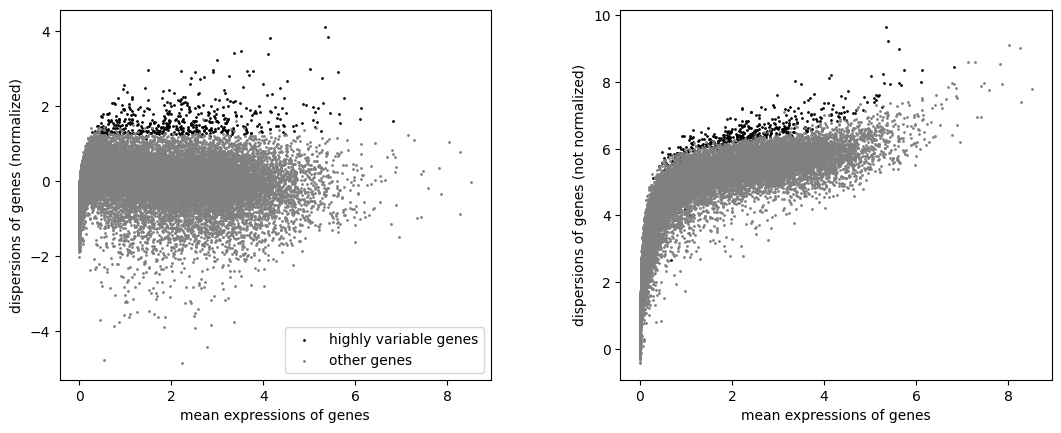

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=500, batch_key="Sample.name", flavor='seurat')
sc.pl.highly_variable_genes(adata)

#### Now follow the clustering steps from the original Darmanis et. al 2017 paper. This entails:
1. Select 500 highly variable genes based on over-dispersion (above).  
2. Compute the cell–cell Euclidean distance matrix.  
3. Run t-SNE on the distance matrix.  
4. Cluster the cells into 12 groups using k-means clustering.  

"In brief, we selected genes with the highest over-dispersion (n = 500) and used them to construct a cell-to-cell dissimilarity matrix. We then performed t-distributed stochastic neighbor embedding (tSNE) on the resulting distance matrix to create a 2D map of all cells. Finally, we used k-means clustering on the 2D tSNE map, resulting in the identification of 12 distinct cell types within separate clusters (Figure 2A)."

In [12]:
# 1) Select just the highly variable genes
adata_hvg = adata[:, adata.var['highly_variable']]
X = adata_hvg.X
# 2) Create cell-cell distance matrix
dist_matrix = squareform(pdist(X, metric='euclidean'))
# 3) Run tSNE on the distance matrix
tsne = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=50,
    init='random',
    random_state=RANDOM_SEED
)
coords = tsne.fit_transform(dist_matrix)

# 4) Run KMeans with k=12 on the same coords
kmeans = KMeans(n_clusters=12, random_state=RANDOM_SEED).fit(coords)
cluster_labels = kmeans.labels_.astype(str)
unique_clusters = np.unique(cluster_labels)
cmap20     = plt.get_cmap('tab20')
clust_colors = {cl: cmap20(i) for i, cl in enumerate(unique_clusters)}

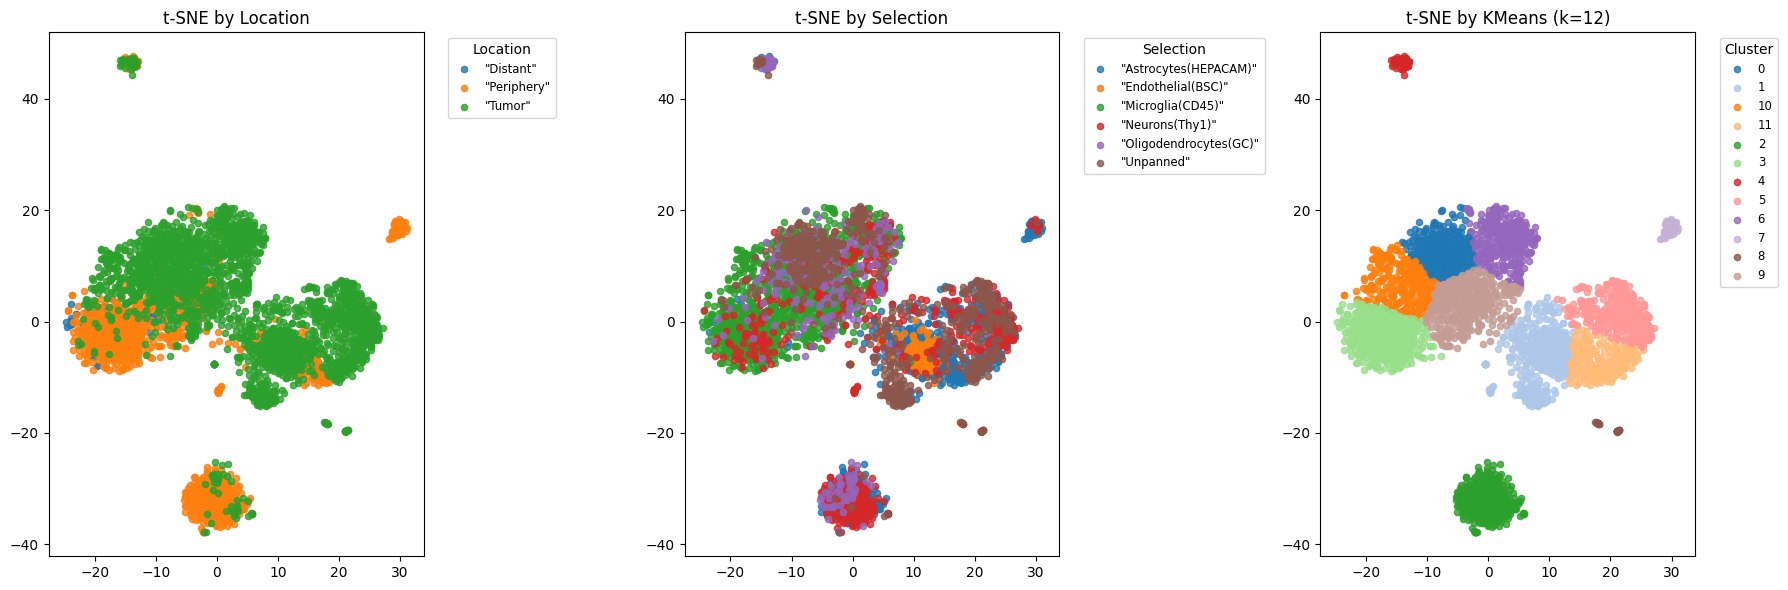

In [13]:
# Let's visualize the tSNE across the location of the cells and the cell types
locations  = adata_hvg.obs['Location'].astype(str).values
selections = adata_hvg.obs['Selection'].astype(str).values

unique_locs = np.unique(locations)
unique_sels = np.unique(selections)
cmap10      = plt.get_cmap('tab10')
loc_colors  = {loc: cmap10(i) for i, loc in enumerate(unique_locs)}
sel_colors  = {sel: cmap10(i) for i, sel in enumerate(unique_sels)}


#Plot 1×3 panel
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# — Left: by Location
ax = axes[0]
for loc in unique_locs:
    mask = (locations == loc)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[loc_colors[loc]], label=loc, s=20, alpha=0.8)
ax.set_title('t-SNE by Location')
ax.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# — Middle: by cell type
ax = axes[1]
for sel in unique_sels:
    mask = (selections == sel)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[sel_colors[sel]], label=sel, s=20, alpha=0.8)
ax.set_title('t-SNE by Selection')
ax.legend(title='Selection', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# — Right: by KMeans clusters
ax = axes[2]
for cl in unique_clusters:
    mask = (cluster_labels == cl)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[clust_colors[cl]], label=cl, s=20, alpha=0.8)
ax.set_title('t-SNE by KMeans (k=12)')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.show()

#### No information was given on the 12 clusters were chosen in the paper. Maybe they used commonly used metrics such as Silhouette score, or the Gap statistic to pick their number of clusters. Let's try them out. If they did, then the highest values, or at least the elbows on the plots, should be seen as k = 12.

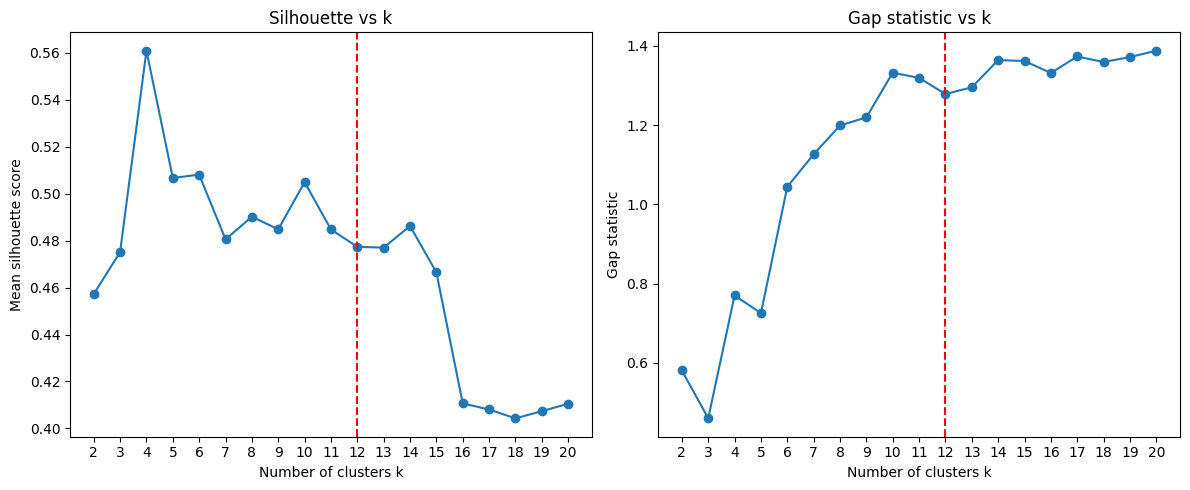

In [14]:
# Scan over 2 to 20 clusters
ks = range(2, 21)
B  = 20
sil_scores = []
gap_stats   = []

# precompute bounding box of your t-SNE map
mins = coords.min(axis=0)
maxs = coords.max(axis=0)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit(coords)
    labels = km.labels_
    sil_scores.append(silhouette_score(coords, labels))

    Wk = np.sum((coords - km.cluster_centers_[labels])**2)
    Wk_refs = []
    for _ in range(B):
        ref = np.random.uniform(mins, maxs, size=coords.shape)
        km_ref = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit(ref)
        Wk_refs.append(np.sum((ref - km_ref.cluster_centers_[km_ref.labels_])**2))

    log_Wk    = np.log(Wk)
    log_Wkref = np.log(Wk_refs)
    gap_stats.append(log_Wkref.mean() - log_Wk)

# ---- plot side by side ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5), tight_layout=True)

# Silhouette plot
ax = axes[0]
ax.plot(list(ks), sil_scores, marker='o')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Mean silhouette score')
ax.set_title('Silhouette vs k')

# Gap statistic plot
ax = axes[1]
ax.plot(list(ks), gap_stats, marker='o', linestyle='-')
ax.axvline(12, color='red', linestyle='--', linewidth=1.5)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Gap statistic')
ax.set_title('Gap statistic vs k')

plt.show()

#### So we can see that neither of these metrics would lead us to choose 12 clusters. We tried our best to recapitulate their clustering pipeline given the details in the paper, but what if we had made different choices (different numbers of highly variable genes, or not accounting for batch effects)? How would our clustering have changed?

#### Here we try different choices of HVG numbers and accounting for batch effects vs. not. Other choices could include the method of selecting HVGs, seed when running tSNE or KMeans, etc.

In [15]:
adata = ad.read_h5ad("data/darmanis_fromraw.h5ad")

def process_hvg(data, batch, n_genes=500):
    # 1) Select HVGs
    if batch == None:
        sc.pp.highly_variable_genes(data, n_top_genes=n_genes, flavor='seurat')
    else:
        sc.pp.highly_variable_genes(data, n_top_genes=n_genes, batch_key="Sample.name", flavor='seurat')
    data_hvg = data[:, data.var['highly_variable']]

    # 2) Build cell-to-cell dissimilarity (Euclidean) matrix
    X = data_hvg.X  # shape (n_cells, 500)
    dist_matrix = squareform(pdist(X, metric='euclidean'))

    tsne = TSNE(
        n_components=2,
        metric='precomputed',
        perplexity=50,
        init='random',      # ← change here
        random_state=RANDOM_SEED
    )
    X_tsne = tsne.fit_transform(dist_matrix) 
    kmeans = KMeans(n_clusters=12, random_state=RANDOM_SEED).fit(X_tsne)
    labels = kmeans.labels_  

    return X_tsne, labels

X_tsne500, labels500 = process_hvg(data=adata, n_genes=500, batch = None)
X_tsne1000, labels1000 = process_hvg(data=adata, n_genes=1000, batch = None)
X_tsne2000, labels2000 = process_hvg(data=adata, n_genes=2000, batch = None)
X_tsne500_batch, labels500_batch = process_hvg(data=adata, n_genes=500, batch = 'Sample.name')
X_tsne1000_batch, labels1000_batch = process_hvg(data=adata, n_genes=1000, batch = 'Sample.name')
X_tsne2000_batch, labels2000_batch = process_hvg(data=adata, n_genes=2000, batch = 'Sample.name')


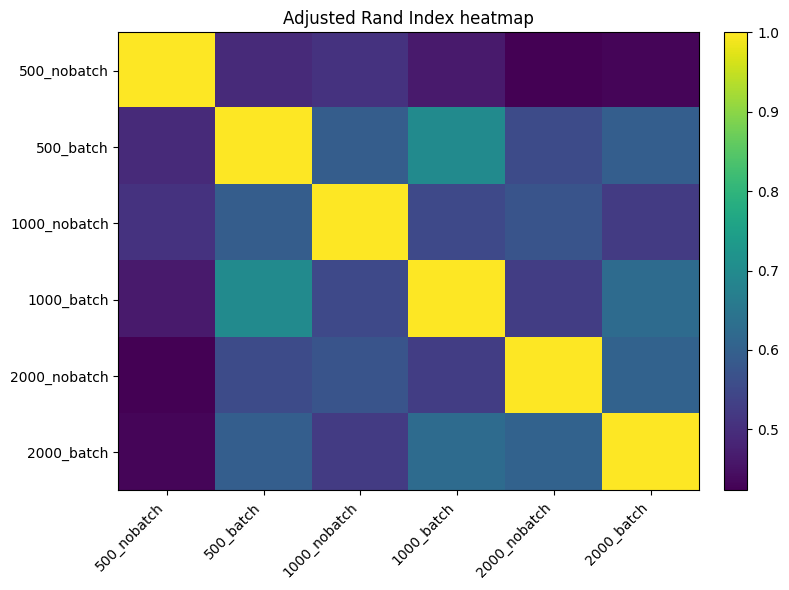

In [23]:
from itertools import combinations

# Now look at how similar the results are to each other across these choices. How sensitive are our results to these choices?

labels_dict = {
    '500_nobatch':       labels500,
    '500_batch':    labels500_batch,
    '1000_nobatch':    labels1000,
    '1000_batch':    labels1000_batch,
    '2000_nobatch':      labels2000,
    '2000_batch':   labels2000_batch,
}

# prepare an empty DataFrame to hold the ARI matrix
ari_df = pd.DataFrame(
    index=labels_dict.keys(),
    columns=labels_dict.keys(),
    dtype=float
)

# fill diagonal with 1.0
for name in labels_dict:
    ari_df.loc[name, name] = 1.0

# compute pairwise ARI
for (n1, l1), (n2, l2) in combinations(labels_dict.items(), 2):
    ari = adjusted_rand_score(l1, l2)
    ari_df.loc[n1, n2] = ari
    ari_df.loc[n2, n1] = ari


fig, ax = plt.subplots(figsize=(8, 6))

# draw the heatmap
im = ax.imshow(ari_df.values, aspect='auto')

# set tick positions and labels
n = len(ari_df)
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(ari_df.columns, rotation=45, ha='right')
ax.set_yticklabels(ari_df.index)

# add a colorbar
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title('Adjusted Rand Index heatmap')
plt.tight_layout()
plt.show()

#### As we can see above, the ARI between different clustering pipeline choices is very low. This shows that the clustering pipeline described in the initial study is **highly sensitive** to data perturbations. Does this cast the reliability of these results into question? Here, we will describe how to incorporate validation strategies to ensure greater reliability of the clustering.

```plaintext
Algorithm: Model Explorer - Ben-Hur et al., 2002

Input:
  X               # a dataset
  k_max           # maximum number of clusters
  num_subsamples  # number of subsamples

Output:
  S(i, k)         # similarities for each k and each pair of subsamples

Require:
  cluster(X, k)   # a clustering algorithm that returns labels
  s(L1, L2)       # a similarity measure between two label‐vectors

1.  f ← 0.8
2.  for k ← 2 to k_max do
3.      for i ← 1 to num_subsamples do
4.          sub1 ← subsamp(X, f)        ⟨a subsample of fraction f⟩
5.          sub2 ← subsamp(X, f)
6.          L1   ← cluster(sub1, k)
7.          L2   ← cluster(sub2, k)
8.          Intersect ← sub1 ∩ sub2
9.          S(i, k) ← s( L1[Intersect], L2[Intersect] )
            ⟨compute similarity on points common to both subsamples⟩
10.     end for
11. end for

Here, we use num_subsamples = 100, and L() as the adjusted rand index (ARI).

In [24]:
#    Assumes X_tsne* and labels* are defined as before.
datasets = {
    '500_nobatch':   (X_tsne500,       labels500),
    '1000_nobatch':  (X_tsne1000,      labels1000),
    '2000_nobatch':  (X_tsne2000,      labels2000),
    '500_batch':     (X_tsne500_batch, labels500_batch),
    '1000_batch':    (X_tsne1000_batch,labels1000_batch),
    '2000_batch':    (X_tsne2000_batch,labels2000_batch),
}

splits = {}
for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y
    )
    splits[name] = {
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test
    }

# 2) Now run stability across k = 2…20
k_max           = 20
subsample_frac  = 0.8
n_runs          = 100

stability_results_500         = {}
stability_results_1000        = {}
stability_results_2000        = {}
stability_results_500_batch   = {}
stability_results_1000_batch  = {}
stability_results_2000_batch  = {}

for k in tqdm(range(2, k_max + 1)):
    clusterer = KMeans(n_clusters=k, random_state=42)
    stability_results_500[k]        = cluster_stability(splits['500_nobatch' ]['X_train'], clusterer, subsample_frac, n_runs)
    stability_results_1000[k]       = cluster_stability(splits['1000_nobatch']['X_train'], clusterer, subsample_frac, n_runs)
    stability_results_2000[k]       = cluster_stability(splits['2000_nobatch']['X_train'], clusterer, subsample_frac, n_runs)
    stability_results_500_batch[k]  = cluster_stability(splits['500_batch'   ]['X_train'], clusterer, subsample_frac, n_runs)
    stability_results_1000_batch[k] = cluster_stability(splits['1000_batch'  ]['X_train'], clusterer, subsample_frac, n_runs)
    stability_results_2000_batch[k] = cluster_stability(splits['2000_batch'  ]['X_train'], clusterer, subsample_frac, n_runs)

  0%|          | 0/19 [00:00<?, ?it/s]

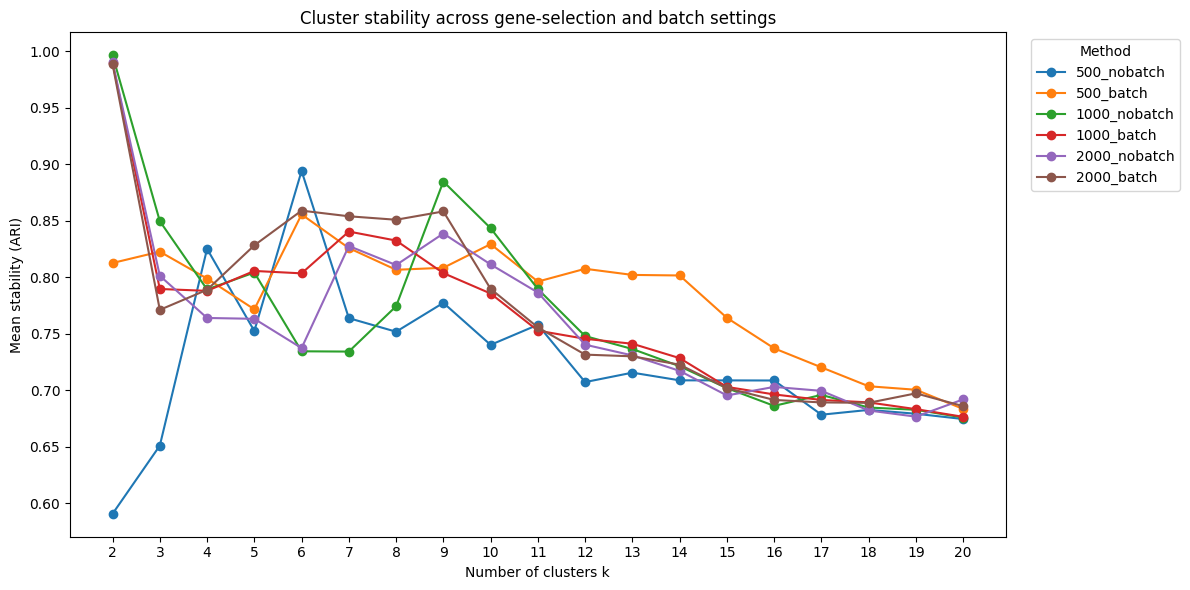

In [25]:

# Collect sorted k values
k_vals = sorted(stability_results_500.keys())

# Build a DataFrame of mean stabilities
df = pd.DataFrame({
    '500_nobatch':   [stability_results_500[k][0]      for k in k_vals],
    '500_batch':     [stability_results_500_batch[k][0]for k in k_vals],
    '1000_nobatch':   [stability_results_1000[k][0]      for k in k_vals],
    '1000_batch':     [stability_results_1000_batch[k][0]for k in k_vals],
    '2000_nobatch':  [stability_results_2000[k][0]     for k in k_vals],
    '2000_batch':    [stability_results_2000_batch[k][0] for k in k_vals],
}, index=k_vals)

# Plot all lines on one axis
fig, ax = plt.subplots(figsize=(12, 6))
for label in df.columns:
    ax.plot(df.index, df[label], marker='o', label=label)

# Formatting
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Mean stability (ARI)')
ax.set_title('Cluster stability across gene‐selection and batch settings')
ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_locator(MultipleLocator(1))  # integer ticks

plt.tight_layout()
plt.show()

#### From this plot, there doesn't seem to be a clear consensus on the number of clusters across processing choices. It could be 2, 6, or 10. The final determination will rely on assessing the data and biological interpretations. We first will look at *k* = 6.

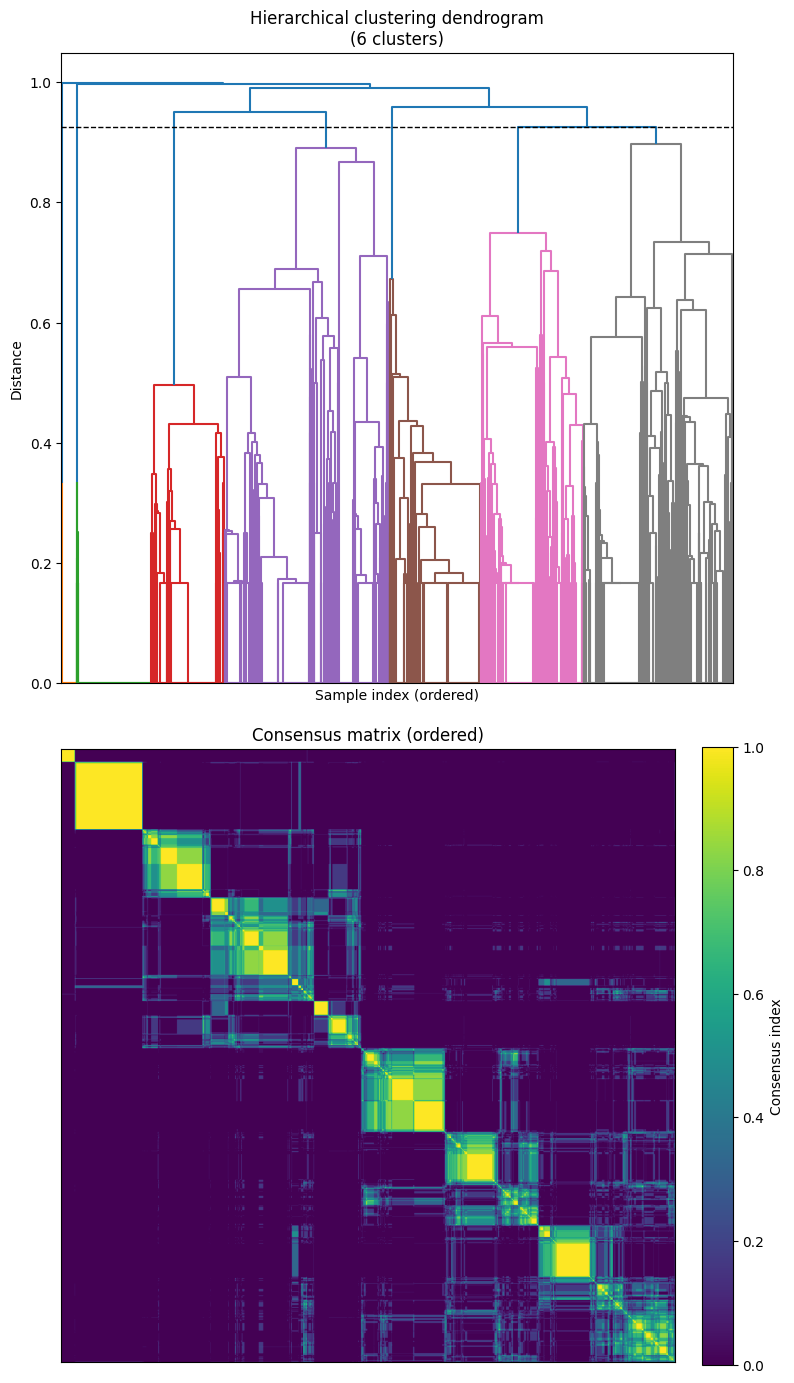

In [26]:
# Collect your label‐arrays in a dict (each of length n_cells)
labels_dict = {
    '500_nobatch':   labels500,
    '500_batch':     labels500_batch,
    '1000_nobatch':  labels1000,
    '1000_batch':    labels1000_batch,
    '2000_nobatch':  labels2000,
    '2000_batch':    labels2000_batch,
}
labels_list = list(labels_dict.values())
n = len(labels_list[0])
M = len(labels_list)

# Build consensus matrix
consensus = np.zeros((n, n), dtype=float)
for lbls in labels_list:
    consensus += (lbls[:, None] == lbls[None, :]).astype(float)
consensus /= M  # average over labelings

# Hierarchical clustering on 1 - consensus, using the same linkage ('average') as before
dist      = 1.0 - consensus
condensed = squareform(dist, checks=False)
Z         = linkage(condensed, method='average')

# Cut the tree to get 6 consensus clusters
consensus_labels = fcluster(Z, t=6, criterion='maxclust')

# Obtain dendrogram order (leaf indices)
dendro = dendrogram(Z, no_plot=True)
order  = dendro['leaves']

# Plot 1×2 panel
fig, axes = plt.subplots(2, 1, figsize=(8, 14), tight_layout=True)

# — Left: Consensus heatmap (ordered by dendrogram)
consensus_ord = consensus[np.ix_(order, order)]
ax = axes[1]
im = ax.imshow(consensus_ord, vmin=0, vmax=1, cmap='viridis')
ax.set_title('Consensus matrix (ordered)')
ax.set_xticks([])
ax.set_yticks([])
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Consensus index')

# — Right: Dendrogram with 6 clusters highlighted
ax = axes[0]
# compute threshold corresponding to 6 clusters
# the distance at which the tree is cut to form 6 clusters is the linkage distance
# of the (n-6)th merge, which is Z[-6,2]
threshold = Z[-6, 2]
dendrogram(
    Z,
    no_labels=True,
    color_threshold=threshold,
    ax=ax
)
# add horizontal line showing the cut
ax.axhline(y=threshold, color='k', linestyle='--', linewidth=1)
ax.set_title('Hierarchical clustering dendrogram\n(6 clusters)')
ax.set_xlabel('Sample index (ordered)')
ax.set_ylabel('Distance')

plt.show()

#### To look at sample-wise and cluster-wise variability, we can take the mean of each consensus clustering row as a measure of stability, and a mean of each cluster-wise block for group-wise measures, and then visualize them on the tSNE plot.

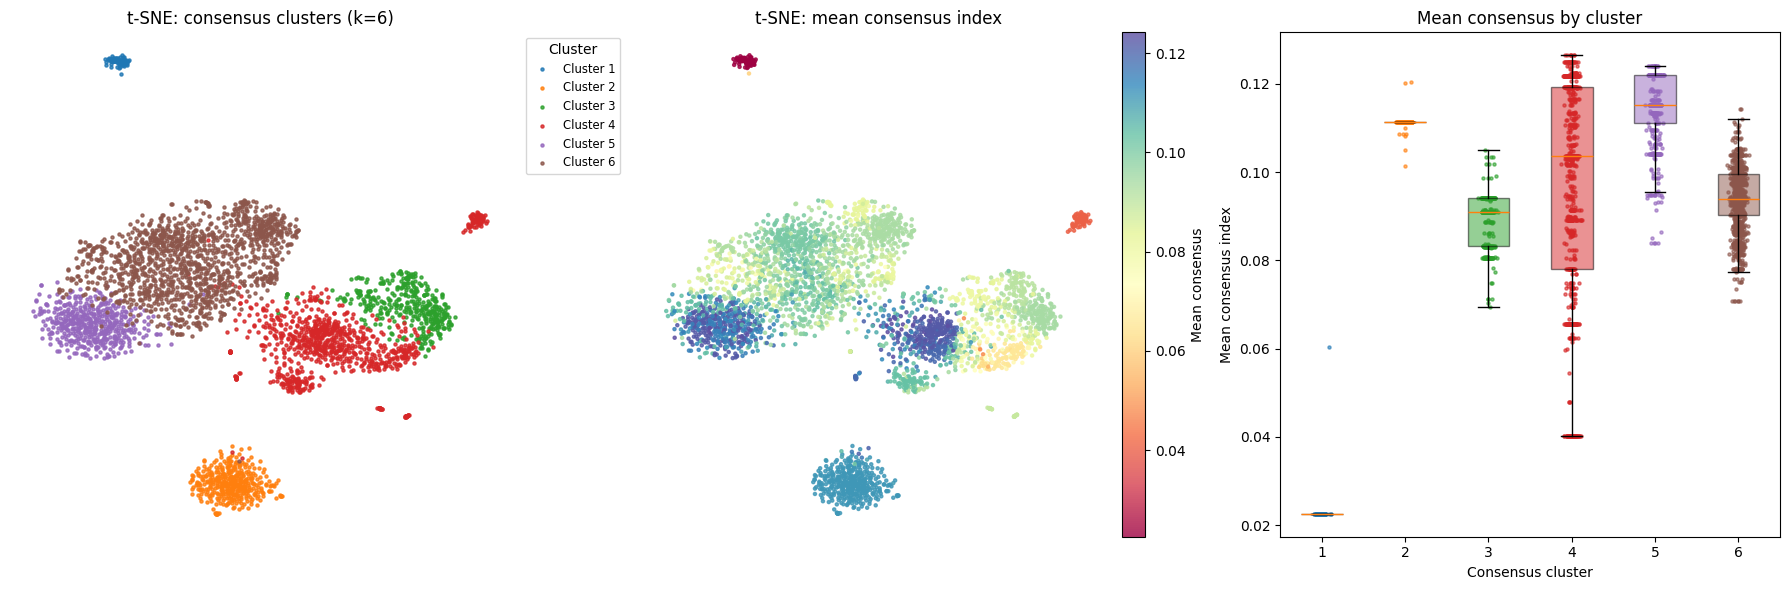

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

# 1) Hierarchical consensus clustering setup
dist      = 1.0 - consensus
condensed = squareform(dist, checks=False)
Z         = linkage(condensed, method='average')
consensus_labels = fcluster(Z, t=6, criterion='maxclust')

mean_consensus = consensus.mean(axis=1)
vmin, vmax     = np.percentile(mean_consensus, [1, 99])

unique_clusters = np.unique(consensus_labels)
cluster_colors  = {cl: f'C{i}' for i, cl in enumerate(unique_clusters)}

df = pd.DataFrame({
    'cluster':        consensus_labels,
    'mean_consensus': mean_consensus
})

# 2) Plot 1×3 panel with legend on first
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# Panel 1: t-SNE colored by consensus clusters
ax = axes[0]
for cl in unique_clusters:
    mask = (consensus_labels == cl)
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        color=cluster_colors[cl],
        s=5,
        alpha=0.8,
        label=f'Cluster {cl}'
    )
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax.set_axis_off()
ax.set_title('t-SNE: consensus clusters (k=6)')

# Panel 2: t-SNE colored by mean consensus index
ax = axes[1]
sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=mean_consensus,
    cmap='Spectral',
    vmin=vmin,
    vmax=vmax,
    s=5,
    alpha=0.8
)
ax.set_axis_off()
ax.set_title('t-SNE: mean consensus index')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('Mean consensus')

# Panel 3: Boxplots of mean consensus per cluster with points
ax = axes[2]
data_per_cluster = [df.loc[df['cluster'] == cl, 'mean_consensus'].values 
                    for cl in unique_clusters]
bp = ax.boxplot(
    data_per_cluster,
    positions=np.arange(len(unique_clusters)),
    patch_artist=True,
    showfliers=False
)
for patch, cl in zip(bp['boxes'], unique_clusters):
    patch.set_facecolor(cluster_colors[cl])
    patch.set_alpha(0.5)
for i, cl in enumerate(unique_clusters):
    y = data_per_cluster[i]
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, color=cluster_colors[cl], s=5, alpha=0.6)
ax.set_xticks(np.arange(len(unique_clusters)))
ax.set_xticklabels([str(cl) for cl in unique_clusters])
ax.set_xlabel('Consensus cluster')
ax.set_ylabel('Mean consensus index')
ax.set_title('Mean consensus by cluster')

plt.show()

=== Counts by Location ===
Location           "Distant"  "Periphery"  "Tumor"
consensus_cluster                                 
1                          0           48       33
2                          0          354       41
3                          0            0      398
4                          0          184      696
5                         34          435       21
6                         23          168     1154 

=== Proportions by Location ===
Location           "Distant"  "Periphery"   "Tumor"
consensus_cluster                                  
1                   0.000000     0.592593  0.407407
2                   0.000000     0.896203  0.103797
3                   0.000000     0.000000  1.000000
4                   0.000000     0.209091  0.790909
5                   0.069388     0.887755  0.042857
6                   0.017100     0.124907  0.857993 


=== Counts by Selection ===
Selection          "Astrocytes(HEPACAM)"  "Endothelial(BSC)"  \
consensus_cluster   

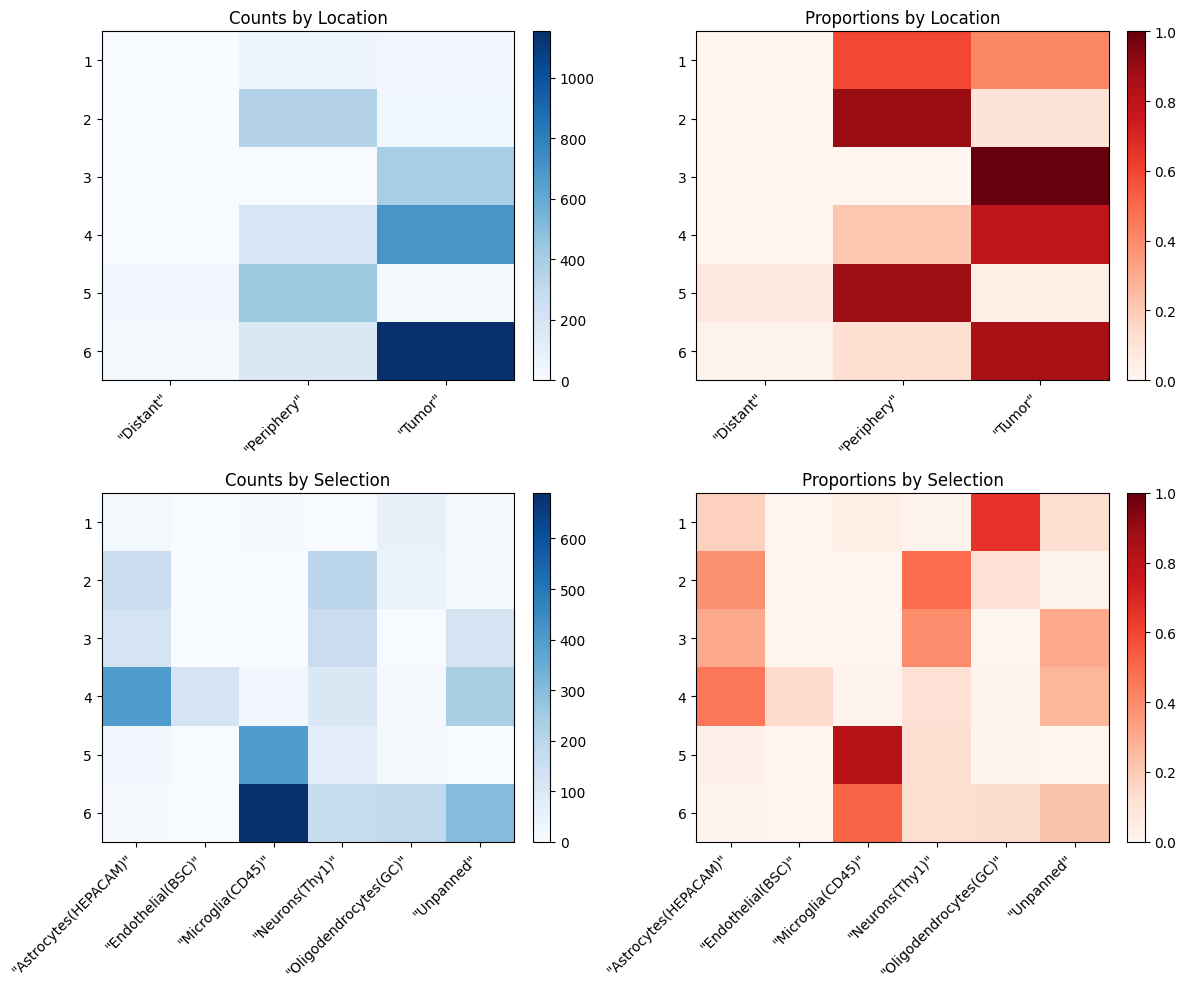

In [28]:
# 1) Add consensus cluster to adata
adata.obs['consensus_cluster'] = consensus_labels.astype(str)

# 2) Crosstabs for raw counts
counts_loc = pd.crosstab(
    adata.obs['consensus_cluster'], 
    adata.obs['Location']
)
counts_sel = pd.crosstab(
    adata.obs['consensus_cluster'], 
    adata.obs['Selection']
)

# 3) Crosstabs for proportions (normalize by row)
prop_loc = counts_loc.div(counts_loc.sum(axis=1), axis=0)
prop_sel = counts_sel.div(counts_sel.sum(axis=1), axis=0)

print("=== Counts by Location ===")
print(counts_loc, "\n")
print("=== Proportions by Location ===")
print(prop_loc, "\n\n")

print("=== Counts by Selection ===")
print(counts_sel, "\n")
print("=== Proportions by Selection ===")
print(prop_sel)
heatmaps = [
    (counts_loc, prop_loc, 'Counts by Location', 'Proportions by Location'),
    (counts_sel, prop_sel, 'Counts by Selection', 'Proportions by Selection')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), tight_layout=True)

for (counts_df, prop_df, title_counts, title_prop), (ax1, ax2) in zip(heatmaps, axes):
    # heatmap of raw counts
    im1 = ax1.imshow(counts_df.values, aspect='auto', cmap='Blues')
    ax1.set_title(title_counts)
    ax1.set_xticks(np.arange(counts_df.shape[1]))
    ax1.set_yticks(np.arange(counts_df.shape[0]))
    ax1.set_xticklabels(counts_df.columns, rotation=45, ha='right')
    ax1.set_yticklabels(counts_df.index)
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # heatmap of proportions
    im2 = ax2.imshow(prop_df.values, aspect='auto', cmap='Reds', vmin=0, vmax=1)
    ax2.set_title(title_prop)
    ax2.set_xticks(np.arange(prop_df.shape[1]))
    ax2.set_yticks(np.arange(prop_df.shape[0]))
    ax2.set_xticklabels(prop_df.columns, rotation=45, ha='right')
    ax2.set_yticklabels(prop_df.index)
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.show()

#### Even if we want to still do 12 clusters, we can investigate:

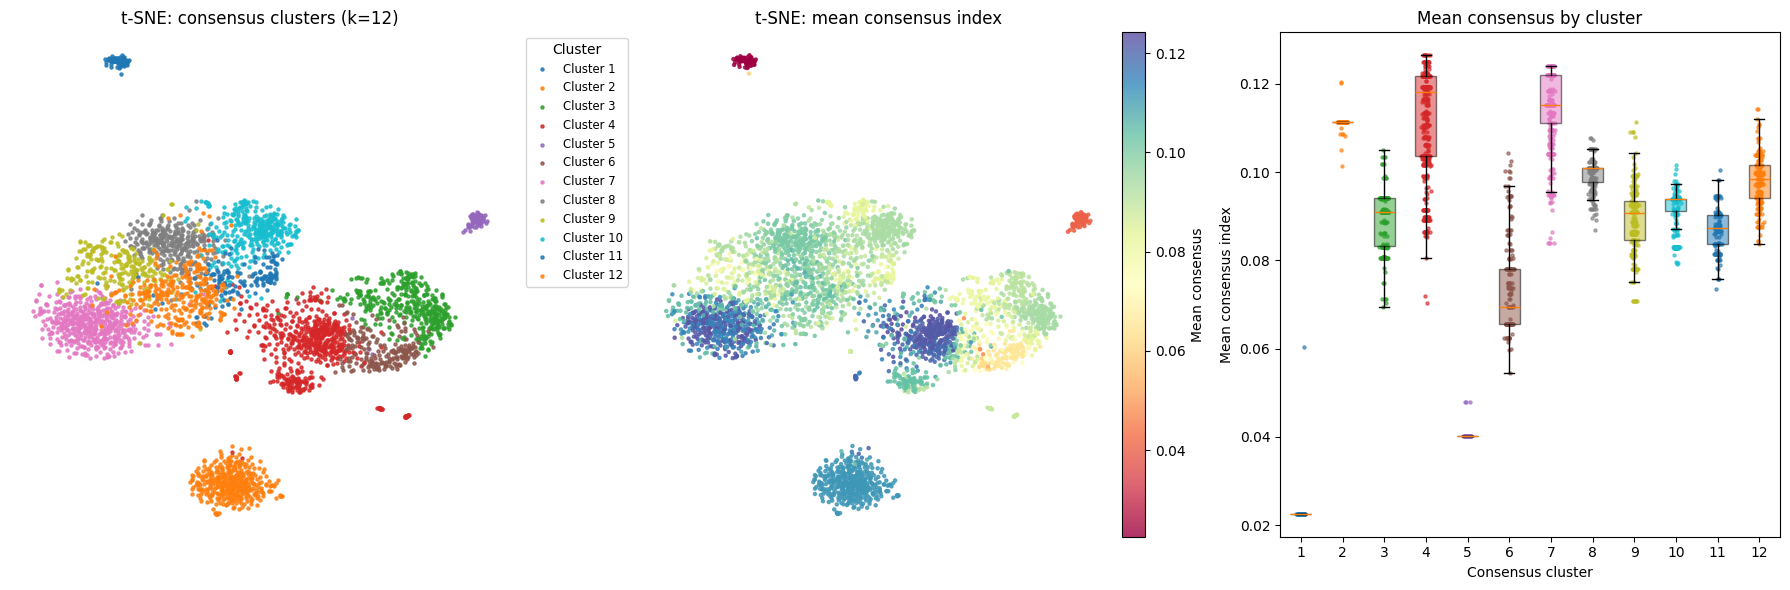

In [29]:
# Hierarchical consensus clustering setup
dist      = 1.0 - consensus
condensed = squareform(dist, checks=False)
Z         = linkage(condensed, method='average')
consensus_labels = fcluster(Z, t=12, criterion='maxclust')

mean_consensus = consensus.mean(axis=1)
vmin, vmax     = np.percentile(mean_consensus, [1, 99])

unique_clusters = np.unique(consensus_labels)
cluster_colors  = {cl: f'C{i}' for i, cl in enumerate(unique_clusters)}

df = pd.DataFrame({
    'cluster':        consensus_labels,
    'mean_consensus': mean_consensus
})

# Plot 1×3 panel with legend on first
fig, axes = plt.subplots(1, 3, figsize=(18, 6), tight_layout=True)

# Panel 1: t-SNE colored by consensus clusters
ax = axes[0]
for cl in unique_clusters:
    mask = (consensus_labels == cl)
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        color=cluster_colors[cl],
        s=5,
        alpha=0.8,
        label=f'Cluster {cl}'
    )
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
ax.set_axis_off()
ax.set_title('t-SNE: consensus clusters (k=12)')

# Panel 2: t-SNE colored by mean consensus index
ax = axes[1]
sc = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=mean_consensus,
    cmap='Spectral',
    vmin=vmin,
    vmax=vmax,
    s=5,
    alpha=0.8
)
ax.set_axis_off()
ax.set_title('t-SNE: mean consensus index')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('Mean consensus')

# Panel 3: Boxplots of mean consensus per cluster with points
ax = axes[2]
data_per_cluster = [df.loc[df['cluster'] == cl, 'mean_consensus'].values 
                    for cl in unique_clusters]
bp = ax.boxplot(
    data_per_cluster,
    positions=np.arange(len(unique_clusters)),
    patch_artist=True,
    showfliers=False
)
for patch, cl in zip(bp['boxes'], unique_clusters):
    patch.set_facecolor(cluster_colors[cl])
    patch.set_alpha(0.5)
for i, cl in enumerate(unique_clusters):
    y = data_per_cluster[i]
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, color=cluster_colors[cl], s=5, alpha=0.6)
ax.set_xticks(np.arange(len(unique_clusters)))
ax.set_xticklabels([str(cl) for cl in unique_clusters])
ax.set_xlabel('Consensus cluster')
ax.set_ylabel('Mean consensus index')
ax.set_title('Mean consensus by cluster')

plt.show()